- yolo的原始官网：
    - `https://pjreddie.com/darknet/`
    - `https://github.com/ultralytics/ultralytics`

# 1. 环境

In [1]:
!pip install ultralytics -q

In [3]:
pip list | find "ultralytics"

ultralytics               8.3.235
ultralytics-thop          2.0.18
Note: you may need to restart the kernel to use updated packages.


# 2. 使用模型的能力

- 直接使用预训练模型（30-400%可以满足需求）。
- 使用别人的算法训练自己的模型：
    - 重新训练
    - 迁移训练：（固化某些网络层，只训练需要的层）
        - 微调属于特殊的迁移学习
- 改造，重新实现自己的网络，重新训练，重新评估 

# 3. 使用yolo模型

- yolo网络的能力：
    - 目标侦测(我们使用的是transformers的模型【FPS处理能力无法胜任商业应用】)
    - 目标分割(语义分割，实例分割，全景分割)：
    - 姿势检测(检测人体的关键部位)
    - 看图说话
    - 图像分类

- 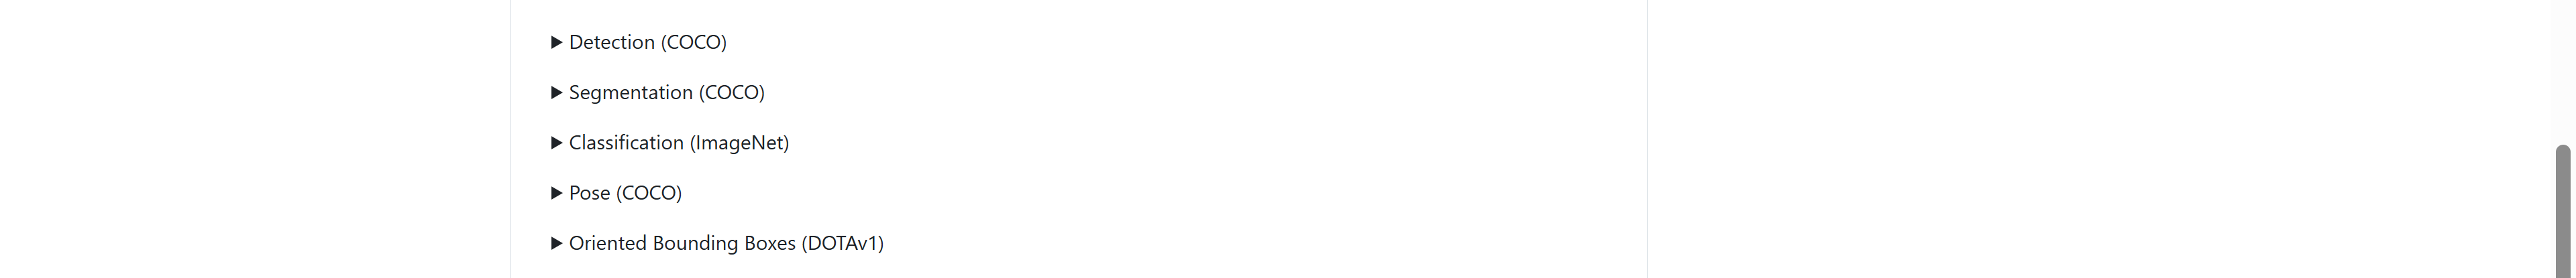

## 3.1. 下载模型

- `https://github.com/ultralytics/assets/releases/download/v8.4.0/yolo26l.pt`
- `https://github.com/ultralytics/assets/releases/download/v8.4.0/yolo26l-seg.pt`

## 3.2. 模型推理

- 条件：
    - 环境
    - 模型下载好
    - 图片
- 重点：
    - 理解推理后返回的数据。

In [1]:
# 1. 引用模块
from ultralytics import YOLO

In [2]:
# ?YOLO   # 摘要帮助
# help(YOLO)   # 详细帮助
# dir(YOLO)  # 查看成员

In [3]:
# 2. 加载模型
dect = YOLO("./yolo26m.pt")

In [5]:
dect=dect.cpu()
# dect=dect.xpu()   # 安装xpu版本的torch，torchvision torchaudio

In [5]:
# 3. 推理(dect对象是可调用对象__call__==forward)
objs = dect(["jiaotong.jpg", "jiaotong.jpg"])  # 把对象当成函数使用


0: 480x640 3 persons, 5 cars, 1 truck, 584.9ms
1: 480x640 3 persons, 5 cars, 1 truck, 584.9ms
Speed: 15.9ms preprocess, 584.9ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 640)


In [17]:
objs   # 检测的目标

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted p

- 代码说明：
    - 返回的肯定是列表list（每个元素对应输入的图片）

In [19]:
# 4. 解析推理的结果数据
boxes = objs[0].boxes

In [20]:
boxes

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([0., 0., 0., 2., 2., 2., 2.], device='cuda:0')
conf: tensor([0.8953, 0.8802, 0.6711, 0.5197, 0.5070, 0.3661, 0.2558], device='cuda:0')
data: tensor([[2.8635e+02, 9.3358e+02, 8.6902e+02, 3.0060e+03, 8.9526e-01, 0.0000e+00],
        [1.1993e+03, 1.0022e+03, 1.6890e+03, 2.3619e+03, 8.8017e-01, 0.0000e+00],
        [2.8862e+03, 8.6596e+02, 3.4702e+03, 1.2409e+03, 6.7114e-01, 0.0000e+00],
        [6.3402e+01, 1.0909e+03, 2.9040e+02, 1.2578e+03, 5.1968e-01, 2.0000e+00],
        [6.8788e+02, 1.0962e+03, 1.4065e+03, 2.1718e+03, 5.0697e-01, 2.0000e+00],
        [7.1271e-02, 1.0852e+03, 9.9586e+01, 1.2059e+03, 3.6612e-01, 2.0000e+00],
        [1.2765e+03, 1.0453e+03, 4.0809e+03, 3.0707e+03, 2.5581e-01, 2.0000e+00]], device='cuda:0')
id: None
is_track: False
orig_shape: (3072, 4096)
shape: torch.Size([7, 6])
xywh: tensor([[ 577.6829, 1969.7686,  582.6667, 2072.3799],
        [1444.1403, 1682.0735,  489.7253, 1359.6782],
       

In [21]:
names = objs[0].names

In [22]:
names

{0: 'person',
 1: 'bicycle',
 2: 'car',
 3: 'motorcycle',
 4: 'airplane',
 5: 'bus',
 6: 'train',
 7: 'truck',
 8: 'boat',
 9: 'traffic light',
 10: 'fire hydrant',
 11: 'stop sign',
 12: 'parking meter',
 13: 'bench',
 14: 'bird',
 15: 'cat',
 16: 'dog',
 17: 'horse',
 18: 'sheep',
 19: 'cow',
 20: 'elephant',
 21: 'bear',
 22: 'zebra',
 23: 'giraffe',
 24: 'backpack',
 25: 'umbrella',
 26: 'handbag',
 27: 'tie',
 28: 'suitcase',
 29: 'frisbee',
 30: 'skis',
 31: 'snowboard',
 32: 'sports ball',
 33: 'kite',
 34: 'baseball bat',
 35: 'baseball glove',
 36: 'skateboard',
 37: 'surfboard',
 38: 'tennis racket',
 39: 'bottle',
 40: 'wine glass',
 41: 'cup',
 42: 'fork',
 43: 'knife',
 44: 'spoon',
 45: 'bowl',
 46: 'banana',
 47: 'apple',
 48: 'sandwich',
 49: 'orange',
 50: 'broccoli',
 51: 'carrot',
 52: 'hot dog',
 53: 'pizza',
 54: 'donut',
 55: 'cake',
 56: 'chair',
 57: 'couch',
 58: 'potted plant',
 59: 'bed',
 60: 'dining table',
 61: 'toilet',
 62: 'tv',
 63: 'laptop',
 64: 'mou

In [23]:
cls = boxes.cls

In [24]:
cls

tensor([0., 0., 0., 2., 2., 2., 2.], device='cuda:0')

In [25]:
cls = cls.detach().cpu().numpy()

In [27]:
cls=cls.astype(int)

In [28]:
cls

array([0, 0, 0, 2, 2, 2, 2])

In [29]:
for c in cls:
    print(F"类别id：{c}，类别名：{names[c]}")

类别id：0，类别名：person
类别id：0，类别名：person
类别id：0，类别名：person
类别id：2，类别名：car
类别id：2，类别名：car
类别id：2，类别名：car
类别id：2，类别名：car


In [30]:
# 概率
conf = boxes.conf

In [31]:
conf

tensor([0.8953, 0.8802, 0.6711, 0.5197, 0.5070, 0.3661, 0.2558], device='cuda:0')

In [32]:
conf = conf.detach().cpu().numpy()

In [33]:
conf

array([    0.89526,     0.88017,     0.67114,     0.51968,     0.50697,     0.36612,     0.25581], dtype=float32)

In [36]:
xyxy = boxes.xyxy
xyxy = xyxy.detach().cpu().numpy()
xyxy = xyxy.astype(int)
xyxy  # 一行一个目标

array([[ 286,  933,  869, 3005],
       [1199, 1002, 1689, 2361],
       [2886,  865, 3470, 1240],
       [  63, 1090,  290, 1257],
       [ 687, 1096, 1406, 2171],
       [   0, 1085,   99, 1205],
       [1276, 1045, 4080, 3070]])

----

- (a) 模块引入

In [1]:
from ultralytics import YOLO

- (b) 模型加载

In [2]:
seg = YOLO("yolo26l-seg.pt")

- (c) 推理

In [3]:
seg_objs = seg("jiaotong.jpg")


image 1/1 D:\AI2026\02Notes\jiaotong.jpg: 480x640 3 persons, 6 cars, 1 truck, 112.2ms
Speed: 3.0ms preprocess, 112.2ms inference, 20.9ms postprocess per image at shape (1, 3, 480, 640)


In [4]:
seg_objs

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: ultralytics.engine.results.Masks object
 names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 

- (d) 处理推理结果

In [7]:
results = seg_objs[0].masks
# results

- 取实心的mask

In [8]:
data = results.data.cpu().numpy()

- 取空心的边缘

In [11]:
xy = results.xy

In [15]:
data[0, :, :]

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(480, 640), dtype=uint8)

- 显示

480 640


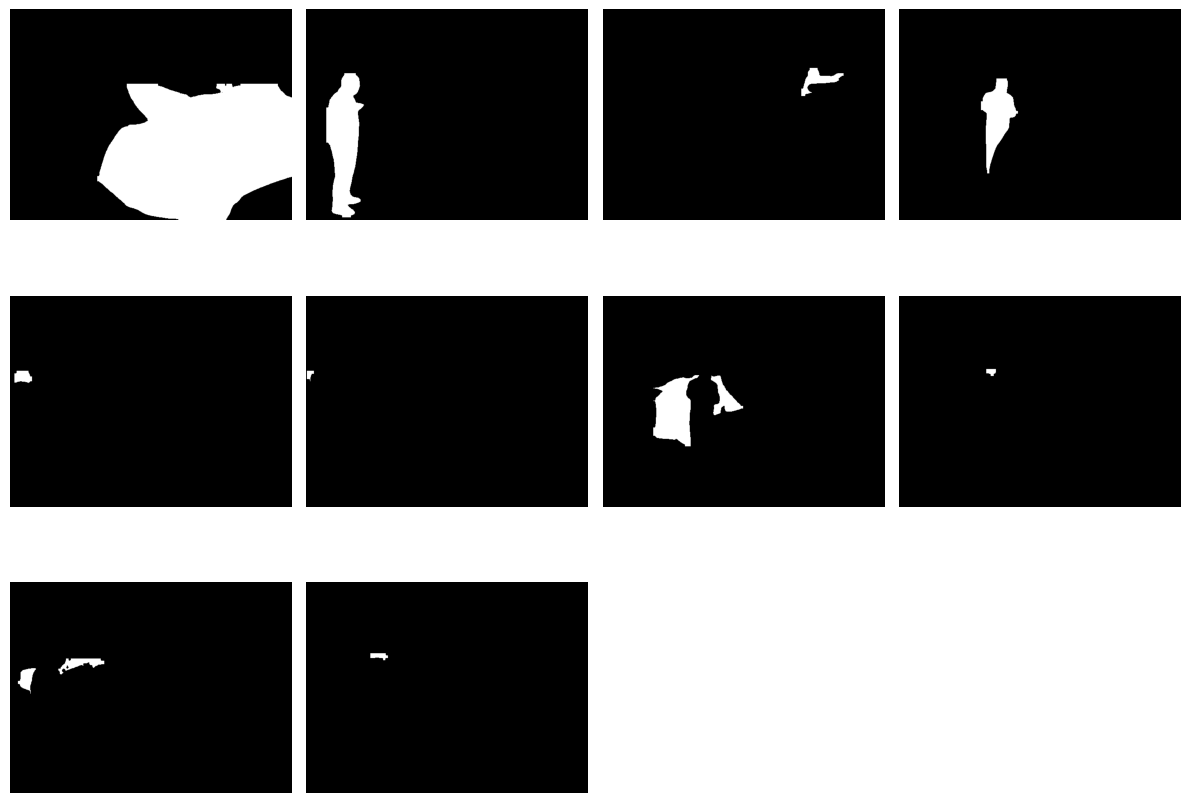

In [25]:
import matplotlib.pyplot as plt

num, h, w = data.shape
print(h, w)
plt.figure(figsize=(4 * 3,  3 * 3))  # 2行，5列的图表，每个图是300像素
plt.subplot(3, 4, 1)
plt.imshow(data[0, :, :], cmap="gray")
plt.axis("off")

plt.subplot(3, 4, 2)
plt.imshow(data[1, :, :], cmap="gray")
plt.axis("off")

plt.subplot(3, 4, 3)
plt.imshow(data[2, :, :], cmap="gray")
plt.axis("off")

plt.subplot(3, 4, 4)
plt.imshow(data[3, :, :], cmap="gray")
plt.axis("off")

plt.subplot(3, 4, 5)
plt.imshow(data[4, :, :], cmap="gray")
plt.axis("off")

plt.subplot(3, 4, 6)
plt.imshow(data[5, :, :], cmap="gray")
plt.axis("off")

plt.subplot(3, 4, 7)
plt.imshow(data[6, :, :], cmap="gray")
plt.axis("off")

plt.subplot(3, 4, 8)
plt.imshow(data[7, :, :], cmap="gray")
plt.axis("off")

plt.subplot(3, 4, 9)
plt.imshow(data[8, :, :], cmap="gray")
plt.axis("off")

plt.subplot(3, 4, 10)
plt.imshow(data[9, :, :], cmap="gray")
plt.axis("off")
plt.tight_layout()
plt.show()

- 挖图的技术

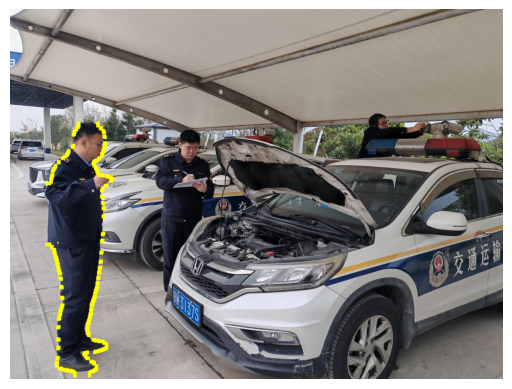

In [36]:
# 取第2个目标的轮廓坐标
import cv2
img  = cv2.imread("jiaotong.jpg", cv2.IMREAD_COLOR_RGB)

o1 = xy[1]
for x, y in o1:
    x = int(x)
    y = int(y)
    img = cv2.rectangle(img, rec=(x, y, 30, 30), color=(255, 255, 0), thickness=-1)
plt.imshow(img)
plt.axis(False)
plt.show()

- 注意：
    - 为了节约空间。返回分割目标的点是按照原尺寸。
    - 但是mask的遮罩使用的是矩阵，所以大小是`480 * 640`

- 挖图的原理：
    - 条件：
        - 0与255构成的黑白二值图。
        - 原图
        - 背景图
    - 目标：
        - 把目标从原图挖出来
        - 把背景图对应目标的地方挖空。
        - 上面两个图叠加完成背景替换。

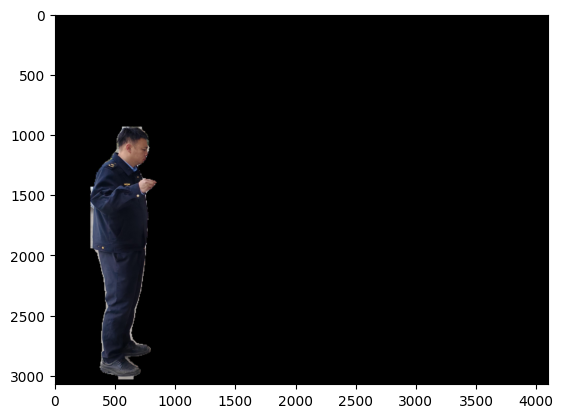

In [44]:
# 把目标从原图挖出来
img  = cv2.imread("jiaotong.jpg", cv2.IMREAD_COLOR_RGB)
# 1. 把黑白图转为三通道彩色图（叠加的原理）：numpy.stack  (torch.stack, torch.cat)
bw_obj = data[1, :, :] * 255
import numpy as np

img_obj = np.stack([bw_obj, bw_obj, bw_obj], axis=2)  # H, W, C
# plt.imshow(img_obj)

# 对图像进行缩放
h, w, _ = img.shape
img_obj = cv2.resize(img_obj, (w, h))
# 2. 运算

img_new = img & img_obj
plt.imshow(img_new)

In [4]:
dir(model_seg)

['T_destination',
 '__annotations__',
 '__call__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_apply',
 '_backward_hooks',
 '_backward_pre_hooks',
 '_buffers',
 '_call_impl',
 '_check_is_pytorch_model',
 '_compiled_call_impl',
 '_forward_hooks',
 '_forward_hooks_always_called',
 '_forward_hooks_with_kwargs',
 '_forward_pre_hooks',
 '_forward_pre_hooks_with_kwargs',
 '_get_backward_hooks',
 '_get_backward_pre_hooks',
 '_get_name',
 '_is_full_backward_hook',
 '_load',
 '_load_from_state_dict',
 '_load_state_dict_post_hooks',
 '_load_state_dict_pre_hooks',
 '_maybe_warn_n

------

## 3.3. 推理数据的处理-图像运算

In [27]:
def detect_objects_by_yolo(img, model_file="./yolo26l-seg.pt"):
    # from ultralytics import YOLO
    import ultralytics  # 网络模型
    import numpy        # 图像运算
    import cv2          # 图像处理
    import torch        # 暂时不直接使用
    
    model_seg = ultralytics.YOLO(model_file)
    # 选择使用gpu还是cpu
    model_seg = model_seg.cuda()  # 使用gpu
    # model_seg.cpu()   # 使用cpu
    results = model_seg(img)[0]   # 基本上都支持（方便）
    # results = model_seg.forward("jiaotong.jpg")[0]  # forward 在YOLO没有实现。 pytorch的标准
    # results = model_seg.predict("jiaotong.jpg")[0]  # 是为了以scikit-learning模块兼容。（机器学习库）
    boxes = results.boxes  # 侦测的目标
    masks = results.masks  # 分隔
    names = results.names  # 用来把id转换为名字
    
    # 名字
    # boxes.cls
    obj_names = [names[int(c)] for c in boxes.cls.cpu().numpy()]   # 生成表达式（逐次生成：效率高）
    # 概率
    obj_confs = boxes.conf.cpu().numpy()   # .tolist()  # numpy数组，python数组
    # 边框
    obj_boxes = boxes.xyxy.cpu().numpy().astype(int)
    # # 分隔目标
    obj_masks = masks.data.cpu().numpy() * 255 # 与原图不一致

    return obj_names, obj_confs, obj_boxes, obj_masks


In [29]:
# detect_objects_by_yolo("jiaotong.jpg")

In [30]:
# help(model_seg.__call__)
# help(model_seg.forward)
# help(model_seg.predict)

In [2]:
# from yq.video_yolo import  detect_objects_by_yolo
# detect_objects_by_yolo("jiaotong.jpg")
import video_yolo
# video_yolo.detect_objects_by_yolo("jiaotong.jpg")
# help(video_yolo.detect_objects_by_yolo)
# video_yolo.main()

- 关于python找模块的方式：
    - 把当前默认查找、
    - ${PYTHON_HOME}/Lib/site-package
    - ~/roaming/python/Lib/site-package
    - ~/Local/python/Lib/site-package
    - 环境变量：${PYTHON_PATH}  

- 文档注释：（边开发，边撰写API手册）
    - 模块文档注释
    - 类文档注释
    - 函数文档知识

In [6]:
# help(zip)
a = zip([1, 2, 3], ["a", "b", "c"])
for x, y in a:
    print(x, y)

1 a
2 b
3 c


- 任务：
    - 1.GPU驱动，torch，torchvision， torchaudio安装gpu版本。
    - 2.代码托管服务器账号，上传全部完成。重点首页的README.md，每个目录下的README.md
    - 3.完成视频的背景替换 + 视频监控的标注。
        - notebook版本(ipynb = interactive python notebook)
        - py程序版本

----